# A Minimal Training Setup on NLB Maze

<html>
<img src="https://camo.githubusercontent.com/38004ff525c31b5088bbac056320ce63b4caaf23d8d0d5aea30b8cf7deba7b73/68747470733a2f2f746f7263682d627261696e2e72656164746865646f63732e696f2f656e2f6c61746573742f5f7374617469632f746f7263685f627261696e5f6c6f676f2e706e67", width="100px">
</html>


This example walks through a minimal training pipeline for decoding 2D hand velocity from motor cortex spiking activity, using the "jenkins_maze_train" recording from the [Neural Latents Benchmark (NLB)](https://neurallatents.github.io/) MC_Maze dataset.

It is intended as a starting point for new users of `torch_brain` and `brainsets`, and shows how to:
1. Build a custom `Dataset` on top of a `brainsets` recording.
2. Sample fixed-length trials around a behavioral event using `TrialSampler`.
3. Train one of three small decoders (a linear readout, a bidirectional GRU, or a dilated TCN).

> ⚠ **Note:**
> Although this notebook will run on a CPU, it is recommended that you use a GPU runtime.
> If you're on Google Colab, do: Runtime > Change runtime type > T4 GPU

## Setup

Install dependencies:

In [ ]:
!pip install scikit-learn matplotlib
!pip install git+https://github.com/neuro-galaxy/torch_brain

And preprocess the dataset using `brainsets`

In [ ]:
!brainsets prepare pei_pandarinath_nlb_2021 --raw-dir data/raw --processed-dir data/processed -s jenkins_maze_train

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import Tensor, nn
from tqdm.auto import tqdm

/home/vinam/proj/neurogalaxy/torch_brain_merge/torch_brain/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Hyperparameters (feel free to play with these)
BIN_SIZE = 0.01  # seconds
BATCH_SIZE = 8
EPOCHS = 100
LR = 1e-3

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Defining a Simple & Custom Dataset

Brainsets provides a dataset class for `PeiPandarinathNLB2021` (which contains the NLB Maze dataset), which basically handles the file I/O.

We subclass this dataset and (re-)define two things on top of it's file I/O:
- **`get_sampling_intervals`**: Decides *which* time windows in the recording count as samples. Here, each sample is a 700 ms window around movement onset, and we split into train/val using the NLB-provided split indicator.
- **`__getitem__`**: Given a time-sliced sample, *how* one is it turned into model-compatible Tensors.

In [3]:
from typing import Literal

from torch_brain.data import Interval
from torch_brain.datasets import DatasetIndex, PeiPandarinathNLB2021
from torch_brain.utils import bin_spikes


class SimpleNLBMazeDataset(PeiPandarinathNLB2021):
    sample_length = 0.7
    out_dim = 2
    out_sampling_rate = 1000.0

    def __init__(self, root: str, split: Literal["train", "val"], bin_size: float):
        # recording_ids picks which session(s) inside the dataset to load.
        # We just want to load the maze_train session
        super().__init__(root=root, recording_ids=["jenkins_maze_train"])

        # This recording only specificies train and validation set
        # and the test set is kept hidden for online evaluation
        assert split in ("train", "val")

        # store some attributes that are useful later
        self.split = split
        self.bin_size = bin_size
        self.out_samples = round(self.sample_length * self.out_sampling_rate)
        self.num_bins = round(self.sample_length / self.bin_size)
        # get_unit_ids returns the list of neurons recorded in this session.
        self.num_units = len(self.get_unit_ids())

    # Contract between Datasets and Samplers:
    # get_sampling_intervals() returns {recording_id: Interval} listing
    # the windows the sampler may draw from.
    # Sampler will emit one DatasetIndex per sample.
    def get_sampling_intervals(self, *_args, **_kwargs):
        rid = self.recording_ids[0]  # since we only have 1 recording
        recording = self.get_recording(rid)

        # Taking trials to be relative to the movement onset time
        # from 250ms before onset to 450ms after onset
        # (as stated in the NLB paper Appendix A.5.1).
        move_onset_times = recording.trials.move_onset_time
        trials = Interval(move_onset_times - 0.25, move_onset_times + 0.45)

        # The NLB dataset also provided us a default assignment of
        # training and validation trials.
        # `.select_by_mask()` is our standard way to filter an Interval
        # down to a subset based on a boolean mask.
        trial_split_indicator = recording.trials.split_indicator.astype(str)
        train_trials = trials.select_by_mask(trial_split_indicator == "train")
        val_trials = trials.select_by_mask(trial_split_indicator == "val")

        if self.split == "train":
            return {rid: train_trials}
        elif self.split == "val":
            return {rid: val_trials}

    # `index` is a DatasetIndex(recording_id, start, end)
    # produced by the sampler.
    def __getitem__(self, index: DatasetIndex):
        # super().__getitem__ returns a sliced view of the recording, with all
        # modalities (.spikes, .units, .hand.vel, ...) already cropped (lazily).
        data = super().__getitem__(index)

        # In this example, we have designed all models to:
        # - take in a Tensor of shape (Number of neurons, Number of bins), and
        # - return a Tensor of shape (Number of output timestep, Output dimension).

        # Spikes are an irregular event stream — bin them into a regular grid.
        X = bin_spikes(data.spikes, num_units=len(data.units), bin_size=self.bin_size)
        X = torch.from_numpy(X).float()  # shape: (num_bins, num_units)

        # Hand velocity is already a regularly-sampled signal, so we just rescale.
        Y = data.hand.vel / 200.0  # appoximate z-score normalization
        Y = torch.from_numpy(Y).float()  # shape: (out_samples, out_dim)
        return X, Y

## Creating the Datasets, Samplers, and DataLoaders

💡 This is where come across the main pattern for creating data pipelines with `torch_brain`:
- **Dataset** tells the sampler *where sampling is allowed*,
- **Sampler** decides *what* samples to load (by emitting `DatasetIndex` objects), and
- **DataLoader** batches the samples as usual.


In [8]:
from torch.utils.data import DataLoader  # standard PyTorch loader

from torch_brain.samplers import TrialSampler

DATA_ROOT = "data/processed"  # This is where we stored the processed dataset

train_ds = SimpleNLBMazeDataset(DATA_ROOT, split="train", bin_size=BIN_SIZE)
# We want to sample "one-trial-at-a-time", so we use the TrialSampler
train_sampler = TrialSampler(
    sampling_intervals=train_ds.get_sampling_intervals(),
    shuffle=True,
)
# Note the sampler is passed explicitly; it is not the default random/sequential
# sampler PyTorch picks for an indexable dataset.
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=train_sampler)
print(f"Number of units: {train_ds.num_units}")
print(f"Number of training samples: {len(train_sampler)}")

# Validation Dataset, Sampler, and DataLoader
val_ds = SimpleNLBMazeDataset(DATA_ROOT, split="val", bin_size=BIN_SIZE)
val_sampler = TrialSampler(sampling_intervals=val_ds.get_sampling_intervals())
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, sampler=val_sampler)
print(f"Number of validation samples: {len(val_sampler)}")

print(f"Number of units:  {train_ds.num_units}")
print(f"Bins per sample:  {train_ds.num_bins}  (bin size = {BIN_SIZE}s)")
print(f"Target samples:   {train_ds.out_samples}  (at {train_ds.out_sampling_rate} Hz)")
print(f"Train trials:     {len(train_ds.get_sampling_intervals()[train_ds.recording_ids[0]])}")
print(f"Val trials:       {len(val_ds.get_sampling_intervals()[val_ds.recording_ids[0]])}")

Number of units: 142
Number of training samples: 75
Number of validation samples: 25
Number of units:  142
Bins per sample:  70  (bin size = 0.01s)
Target samples:   700  (at 1000.0 Hz)
Train trials:     75
Val trials:       25


Let's first peek at a single sample to confirm the shapes match what we expect, and visualize the binned spikes (input) and hand velocity (target) for one trial.

First sample:
    recording_id: jenkins_maze_train,
    start time: 124.188,
    end time: 124.888

X shape: (70, 142)  (num_bins, num_units)
Y shape: (700, 2)  (out_samples, out_dim)


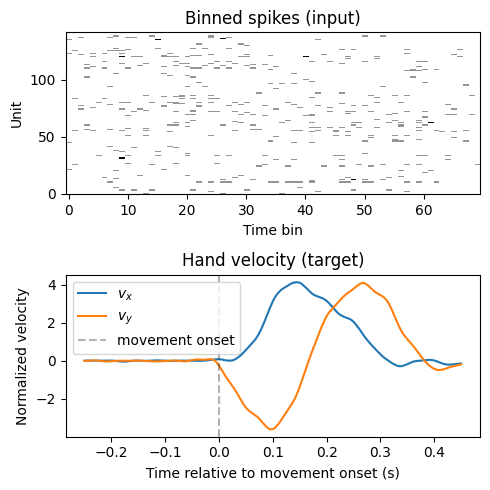

In [ ]:
first_sample_index = next(iter(train_sampler))
print(
    f"First sample:\n"
    f"    recording_id: {first_sample_index.recording_id},\n"
    f"    start time: {first_sample_index.start},\n"
    f"    end time: {first_sample_index.end}\n"
)

X, Y = train_ds[first_sample_index]
print(f"X shape: {tuple(X.shape)}  (num_bins, num_units)")
print(f"Y shape: {tuple(Y.shape)}  (out_samples, out_dim)")

fig, axes = plt.subplots(2, 1, figsize=(5, 5))

axes[0].imshow(X.T.numpy(), aspect="auto", cmap="Greys", origin="lower", interpolation="nearest")
axes[0].set_title("Binned spikes (input)")
axes[0].set_xlabel("Time bin")
axes[0].set_ylabel("Unit")

t = np.linspace(-0.25, 0.45, train_ds.out_samples)
axes[1].plot(t, Y[:, 0].numpy(), label="$v_x$")
axes[1].plot(t, Y[:, 1].numpy(), label="$v_y$")
axes[1].axvline(0, color="k", linestyle="--", alpha=0.3, label="movement onset")
axes[1].set_title("Hand velocity (target)")
axes[1].set_xlabel("Time relative to movement onset (s)")
axes[1].set_ylabel("Normalized velocity")
axes[1].legend()

plt.tight_layout()
plt.show()

## The Model

Three small decoders are defined in the hidden cells below: Linear, GRU, and TCN.

- **Linear**: flatten + a single `nn.Linear` layer.
- **GRU**: bidirectional GRU, then a per-timestep linear readout and an interpolation to upsample from `num_bins` to `out_samples`.
- **TCN**: a stack of dilated 1D convolutions, followed by the same interpolation + readout.

All three follow the same interface:

They take `(batch, num_bins, num_units)` and return `(batch, out_samples, out_dim)`:


### Model Definitions

Feel free to look around here!

#### Linear

In [10]:
class Linear(nn.Module):
    def __init__(self, in_units, in_bins, out_dim, out_samples, dropout=0.2):
        super().__init__()
        self.out_dim = out_dim
        self.out_samples = out_samples

        input_size = in_units * in_bins
        output_size = out_dim * out_samples
        self.net = nn.Sequential(
            nn.Dropout(dropout), nn.Linear(input_size, output_size)
        )

    def forward(self, x: Tensor) -> Tensor:
        batch_size = x.size(0)
        y = self.net(x.flatten(start_dim=1))
        y = y.view(batch_size, self.out_samples, self.out_dim)
        return y

#### GRU

In [11]:
class GRU(nn.Module):
    def __init__(
        self,
        in_units,
        in_bins,
        out_dim,
        out_samples,
        hidden_dim=64,
        num_layers=2,
        bidirectional=True,
        dropout=0.2,
    ):
        super().__init__()
        self.out_dim = out_dim
        self.out_samples = out_samples

        self.gru = nn.GRU(
            input_size=in_units,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=dropout,
        )
        self.readout = nn.Linear(
            in_features=2 * hidden_dim if bidirectional else hidden_dim,
            out_features=out_dim,
        )

    def forward(self, x: Tensor) -> Tensor:
        z, _ = self.gru(x)
        y = self.readout(z)
        y = y.permute(0, 2, 1)  # (B, T, D) ->  (B, D, T)
        y = nn.functional.interpolate(y, self.out_samples, mode="linear")
        y = y.permute(0, 2, 1)  # (B, D, T) -> (B, T, D)
        return y

#### TCN

In [12]:
class TCN(nn.Module):
    def __init__(
        self,
        in_units,
        in_bins,
        out_dim,
        out_samples,
        hidden_dim=64,
        num_layers=8,
        kernel_size=3,
        dropout=0.2,
    ):
        super().__init__()
        self.out_dim = out_dim
        self.out_samples = out_samples

        layers = []
        in_channels = in_units
        for i in range(num_layers):
            dilation = 2**i
            padding = (kernel_size - 1) * dilation // 2
            layers.append(nn.Dropout(dropout))
            layers.append(
                nn.Conv1d(
                    in_channels,
                    hidden_dim,
                    kernel_size,
                    padding=padding,
                    dilation=dilation,
                )
            )
            layers.append(nn.ReLU())
            in_channels = hidden_dim
        self.net = nn.Sequential(*layers)
        self.readout = nn.Linear(hidden_dim, out_dim)

    def forward(self, x: Tensor) -> Tensor:
        z = x.permute(0, 2, 1)  # (B, T, C) -> (B, C, T)
        z = self.net(z)
        z = nn.functional.interpolate(z, self.out_samples, mode="linear")
        z = z.permute(0, 2, 1)  # (B, C, T) -> (B, T, C)
        y = self.readout(z)
        return y

### Instantiating the model

In [13]:
model = GRU(  # try: Linear, GRU, TCN
    in_units=train_ds.num_units,
    in_bins=train_ds.num_bins,
    out_dim=train_ds.out_dim,
    out_samples=train_ds.out_samples,
).to(device)

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTrainable parameters: {num_params:,}")
print(model)


Trainable parameters: 154,626
GRU(
  (gru): GRU(142, 64, num_layers=2, batch_first=True, dropout=0.2, bidirectional=True)
  (readout): Linear(in_features=128, out_features=2, bias=True)
)


## Training

A standard PyTorch loop! MSE loss against the hand velocity, AdamW optimizer, R² score on the validation set at the end of each epoch.

In [14]:
from sklearn.metrics import r2_score

optim = torch.optim.AdamW(model.parameters(), lr=LR)

val_r2_history = []

for _epoch in (epoch_pbar := tqdm(range(EPOCHS))):
    model.train()
    for X, Y in train_loader:
        X, Y = X.to(device), Y.to(device)
        pred = model(X)
        loss = nn.functional.mse_loss(pred, Y)
        optim.zero_grad()
        loss.backward()
        optim.step()

    with torch.no_grad():
        model.eval()
        preds, targets = [], []
        for X, Y in val_loader:
            X, Y = X.to(device), Y.to(device)
            preds.append(model(X))
            targets.append(Y)
        pred = torch.cat(preds).flatten(0, 1).cpu()
        target = torch.cat(targets).flatten(0, 1).cpu()
        r2 = r2_score(target, pred)
        val_r2_history.append(r2)
        epoch_pbar.set_description(f"Val R²: {r2:.3f}")

Val R²: 0.681: 100%|██████████| 100/100 [00:10<00:00,  9.52it/s]


## Evaluation

Plot the R² curve over training and compare predicted vs. actual hand velocity on one validation trial.

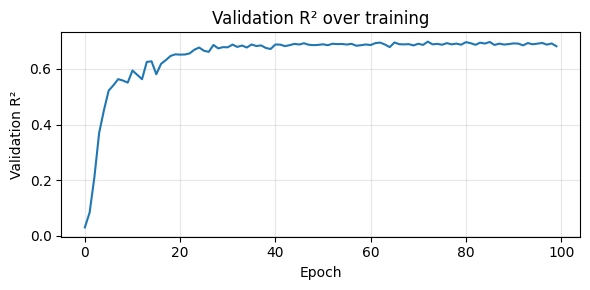

In [15]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(val_r2_history)
ax.set_xlabel("Epoch")
ax.set_ylabel("Validation R²")
ax.set_title("Validation R² over training")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Let's look at an example how our model's predictions compare with the ground truth!

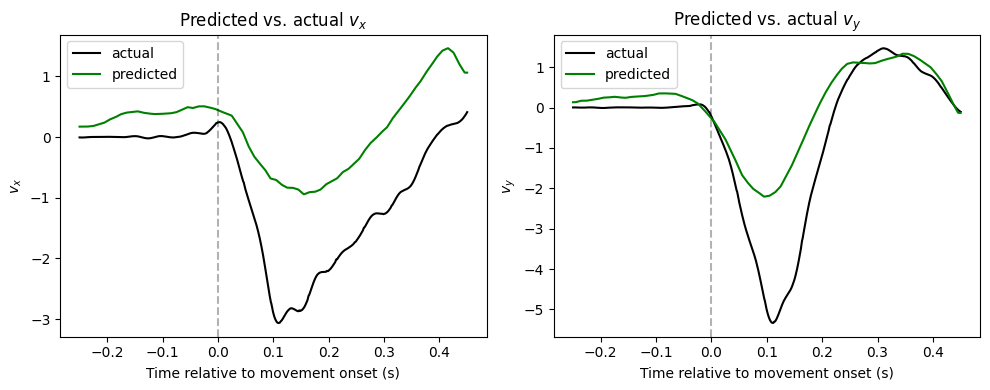

In [16]:
model.eval()
with torch.no_grad():
    X, Y = val_ds[next(iter(val_sampler))]
    pred = model(X.unsqueeze(0).to(device)).squeeze(0).cpu()

t = np.linspace(-0.25, 0.45, val_ds.out_samples)
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=False)
names = ["$v_x$", "$v_y$"]

# Plot $v_x$ and $v_y$
for i, name in enumerate(names):
    axes[i].plot(t, Y[:, i].numpy(), label="actual", color="k")
    axes[i].plot(t, pred[:, i].numpy(), label="predicted", color="green")
    axes[i].axvline(0, color="k", linestyle="--", alpha=0.3)
    axes[i].set_xlabel("Time relative to movement onset (s)")
    axes[i].set_ylabel(name)
    axes[i].legend(loc="upper left")
axes[0].set_title("Predicted vs. actual $v_x$", usetex=False)
axes[1].set_title("Predicted vs. actual $v_y$", usetex=False)

plt.tight_layout()
plt.show()